# Mobile Price Classification: Sections 2 and 3


## Setup


In [20]:
# If you do not use Colab, install the required packages.
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install mlxtend
!pip install jinja2
!pip install scipy


/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=35669) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip


/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=35669) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip


/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=35669) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


...


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip


/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=35669) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip


/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=35669) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

seed = 42


## Section 2: SVM


### Section 2(a): Train/Validation/Test Split and Baseline SVM


In [22]:
# HW2 Section 2(a): train an SVM with C=1.0 on mobile_price.csv
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

mobile_df = pd.read_csv('data/mobile_price.csv')

X_mobile = mobile_df.drop(columns=['price_range'])
y_mobile = mobile_df['price_range']

# Shuffle with random_state=42 and split into 60% train, 20% validation, 20% test.
X_mobile_train, X_mobile_temp, y_mobile_train, y_mobile_temp = train_test_split(
    X_mobile,
    y_mobile,
    test_size=0.4,
    shuffle=True,
    random_state=42,
    stratify=y_mobile,
)

X_mobile_val, X_mobile_test, y_mobile_val, y_mobile_test = train_test_split(
    X_mobile_temp,
    y_mobile_temp,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=y_mobile_temp,
)

print('Dataset sizes:')
print(f'Training: {X_mobile_train.shape[0]} samples')
print(f'Validation: {X_mobile_val.shape[0]} samples')
print(f'Testing: {X_mobile_test.shape[0]} samples')


def build_svm_model(C):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(C=C, kernel='rbf', random_state=42)),
    ])


def evaluate_multiclass_classifier(model, splits):
    rows = []
    for split_name, X_split, y_split in splits:
        y_pred = model.predict(X_split)
        rows.append({
            'split': split_name,
            'accuracy': accuracy_score(y_split, y_pred),
            'f1_weighted': f1_score(y_split, y_pred, average='weighted'),
        })
    return pd.DataFrame(rows)

svm_c1 = build_svm_model(C=1.0)
svm_c1.fit(X_mobile_train, y_mobile_train)

svm_results_c1 = evaluate_multiclass_classifier(
    svm_c1,
    [
        ('train', X_mobile_train, y_mobile_train),
        ('validation', X_mobile_val, y_mobile_val),
        ('test', X_mobile_test, y_mobile_test),
    ],
)

display(svm_results_c1.style.format({'accuracy': '{:.4f}', 'f1_weighted': '{:.4f}'}))


Dataset sizes:
Training: 1200 samples
Validation: 400 samples
Testing: 400 samples


,split,accuracy,f1_weighted
0,train,0.9808,0.9809
1,validation,0.8625,0.8630
2,test,0.8975,0.8979


### Section 2(b): Explore Different C Values


split,test,train,validation
C,,,
0.001000,0.6625,0.7617,0.6600
0.010000,0.6625,0.7617,0.6600
0.100000,0.6675,0.7667,0.6650
1.000000,0.8975,0.9808,0.8625
10.000000,0.8975,1.0000,0.8675
100.000000,0.9025,1.0000,0.8675
1000.000000,0.9025,1.0000,0.8675
10000.000000,0.9025,1.0000,0.8675


split,test,train,validation
C,,,
0.001000,0.6707,0.7660,0.6696
0.010000,0.6707,0.7660,0.6696
0.100000,0.6752,0.7715,0.6753
1.000000,0.8979,0.9809,0.8630
10.000000,0.8978,1.0000,0.8683
100.000000,0.9026,1.0000,0.8683
1000.000000,0.9026,1.0000,0.8683
10000.000000,0.9026,1.0000,0.8683


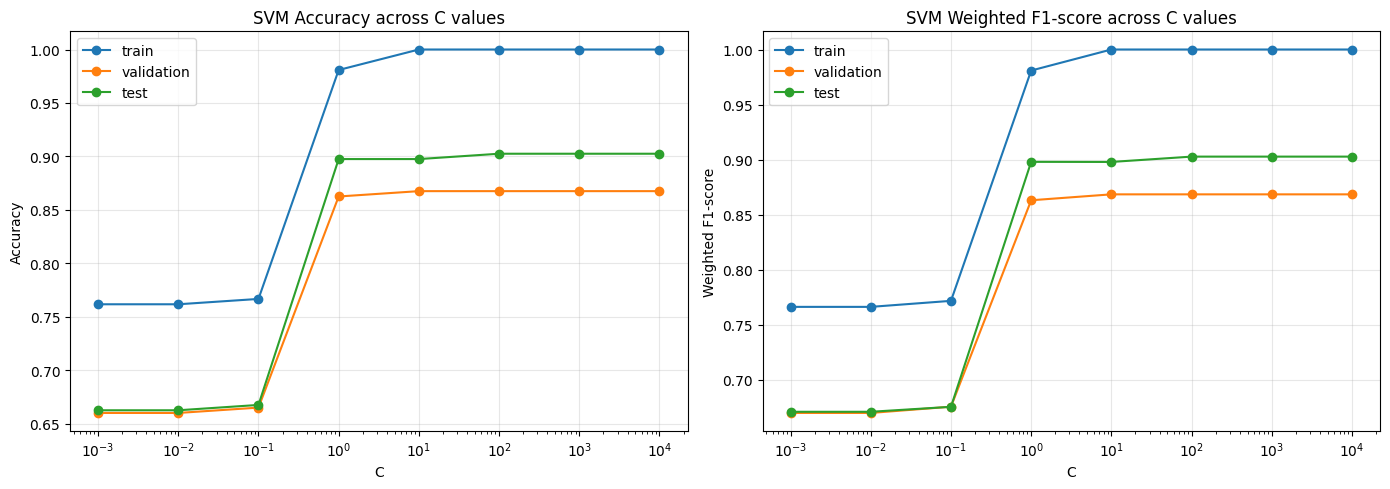

In [23]:
# HW2 Section 2(b): sweep C values and compare accuracy/F1 on train, validation, and test sets
C_values = [10 ** exp for exp in range(-3, 5)]
svm_sweep_records = []

for C in C_values:
    svm_model = build_svm_model(C=C)
    svm_model.fit(X_mobile_train, y_mobile_train)

    for split_name, X_split, y_split in [
        ('train', X_mobile_train, y_mobile_train),
        ('validation', X_mobile_val, y_mobile_val),
        ('test', X_mobile_test, y_mobile_test),
    ]:
        y_pred = svm_model.predict(X_split)
        svm_sweep_records.append({
            'C': C,
            'split': split_name,
            'accuracy': accuracy_score(y_split, y_pred),
            'f1_weighted': f1_score(y_split, y_pred, average='weighted'),
        })

svm_sweep_df = pd.DataFrame(svm_sweep_records)
display(svm_sweep_df.pivot(index='C', columns='split', values='accuracy').style.format('{:.4f}'))
display(svm_sweep_df.pivot(index='C', columns='split', values='f1_weighted').style.format('{:.4f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for split_name in ['train', 'validation', 'test']:
    split_df = svm_sweep_df[svm_sweep_df['split'] == split_name]
    axes[0].plot(split_df['C'], split_df['accuracy'], marker='o', label=split_name)
    axes[1].plot(split_df['C'], split_df['f1_weighted'], marker='o', label=split_name)

axes[0].set_title('SVM Accuracy across C values')
axes[0].set_xlabel('C')
axes[0].set_ylabel('Accuracy')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title('SVM Weighted F1-score across C values')
axes[1].set_xlabel('C')
axes[1].set_ylabel('Weighted F1-score')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### Section 2(c): Generalization Observation


In [24]:
# HW2 Section 2(c): choose the C value with the best validation F1-score
validation_results = svm_sweep_df[svm_sweep_df['split'] == 'validation'].copy()
best_validation = validation_results.sort_values(
    ['f1_weighted', 'accuracy', 'C'], ascending=[False, False, True]
).iloc[0]

best_C = best_validation['C']
best_model_results = svm_sweep_df[svm_sweep_df['C'] == best_C].copy()

display(best_model_results.style.format({'C': '{:.3g}', 'accuracy': '{:.4f}', 'f1_weighted': '{:.4f}'}))

print('Observation:')
print(
    f"The best generalization choice is C={best_C:g}, selected by the highest validation "
    f"weighted F1-score ({best_validation['f1_weighted']:.4f}) and validation accuracy "
    f"({best_validation['accuracy']:.4f}). If multiple C values tie, the smallest C is chosen "
    f"to keep regularization stronger."
)
print(
    "Very small C values underfit because the margin is too strongly regularized, while very large "
    "C values can increase training performance without improving validation performance."
)
print(
    "Therefore, the validation set is used to choose C, and the test set is kept as the final "
    "unseen-data check for that selected model."
)


,C,split,accuracy,f1_weighted
12,10,train,1.0000,1.0000
13,10,validation,0.8675,0.8683
14,10,test,0.8975,0.8978


Observation:
The best generalization choice is C=10, selected by the highest validation weighted F1-score (0.8683) and validation accuracy (0.8675). If multiple C values tie, the smallest C is chosen to keep regularization stronger.
Very small C values underfit because the margin is too strongly regularized, while very large C values can increase training performance without improving validation performance.
Therefore, the validation set is used to choose C, and the test set is kept as the final unseen-data check for that selected model.


## Section 3: Association Rule Mining


### Section 3(a): FP-growth Frequent Patterns


In [25]:
# HW2 Section 3(a): build transactions for price_range=1 and list frequent patterns
from IPython.display import display
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

try:
    mobile_df
except NameError:
    mobile_df = pd.read_csv('data/mobile_price.csv')

arm_features = ['ram', 'int_memory', 'px_width', 'battery_power']
price_1_df = mobile_df[mobile_df['price_range'] == 1].copy()


def categorize_by_range(value, min_value, max_value):
    feature_range = max_value - min_value
    low_upper = min_value + 0.3 * feature_range
    medium_upper = min_value + 0.7 * feature_range

    if value <= low_upper:
        return 'low'
    if value <= medium_upper:
        return 'medium'
    return 'high'


category_boundaries = []
for feature in arm_features:
    min_value = price_1_df[feature].min()
    max_value = price_1_df[feature].max()
    feature_range = max_value - min_value
    category_boundaries.append({
        'feature': feature,
        'min': min_value,
        'low_upper': min_value + 0.3 * feature_range,
        'medium_upper': min_value + 0.7 * feature_range,
        'max': max_value,
    })

category_boundaries_df = pd.DataFrame(category_boundaries)
print(f'Number of samples with price_range=1: {len(price_1_df)}')
print('Category boundaries based on the 3:4:3 range split:')
display(category_boundaries_df.style.format({
    'min': '{:.2f}',
    'low_upper': '{:.2f}',
    'medium_upper': '{:.2f}',
    'max': '{:.2f}',
}))

transactions = []
for _, row in price_1_df.iterrows():
    transaction = []
    for feature in arm_features:
        min_value = price_1_df[feature].min()
        max_value = price_1_df[feature].max()
        category = categorize_by_range(row[feature], min_value, max_value)
        transaction.append(f'{feature}_{category}')
    transactions.append(transaction)

print('First five transactions:')
for transaction in transactions[:5]:
    print(transaction)

transaction_encoder = TransactionEncoder()
transaction_matrix = transaction_encoder.fit(transactions).transform(transactions)
transaction_df = pd.DataFrame(transaction_matrix, columns=transaction_encoder.columns_)

frequent_itemsets = fpgrowth(transaction_df, min_support=0.3, use_colnames=True)
frequent_itemsets['itemsets_text'] = frequent_itemsets['itemsets'].apply(lambda items: ', '.join(sorted(items)))
frequent_itemsets = frequent_itemsets.sort_values(
    ['support', 'itemsets_text'], ascending=[False, True]
).reset_index(drop=True)

print('Frequent patterns with support >= 0.3:')
display(frequent_itemsets[['support', 'itemsets_text']].style.format({'support': '{:.4f}'}))


Number of samples with price_range=1: 500
Category boundaries based on the 3:4:3 range split:


,feature,min,low_upper,medium_upper,max
0,ram,387.00,1114.20,2083.80,2811.00
1,int_memory,2.00,20.60,45.40,64.00
2,px_width,500.00,949.40,1548.60,1998.00
3,battery_power,501.00,949.50,1547.50,1996.00


First five transactions:
['ram_high', 'int_memory_low', 'px_width_low', 'battery_power_low']
['ram_medium', 'int_memory_medium', 'px_width_medium', 'battery_power_high']
['ram_low', 'int_memory_medium', 'px_width_high', 'battery_power_high']
['ram_medium', 'int_memory_medium', 'px_width_low', 'battery_power_high']
['ram_medium', 'int_memory_high', 'px_width_low', 'battery_power_medium']
Frequent patterns with support >= 0.3:


,support,itemsets_text
0,0.6820,ram_medium
1,0.4160,px_width_medium
2,0.4140,battery_power_medium
3,0.4120,int_memory_medium
4,0.3180,"battery_power_medium, ram_medium"
5,0.3160,int_memory_low
6,0.3080,battery_power_low
7,0.3060,"px_width_medium, ram_medium"


### Section 3(b): Association Rules


In [26]:
# HW2 Section 3(b): list rules with support >= 0.3, confidence >= 0.4, and lift >= 0.8
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.4)
rules = rules[(rules['support'] >= 0.3) & (rules['confidence'] >= 0.4) & (rules['lift'] >= 0.8)].copy()

rules['antecedents_text'] = rules['antecedents'].apply(lambda items: ', '.join(sorted(items)))
rules['consequents_text'] = rules['consequents'].apply(lambda items: ', '.join(sorted(items)))
rules = rules.sort_values(
    ['support', 'confidence', 'lift'], ascending=[False, False, False]
).reset_index(drop=True)

print('Association rules with support >= 0.3, confidence >= 0.4, and lift >= 0.8:')
rule_display_cols = ['antecedents_text', 'consequents_text', 'support', 'confidence', 'lift']
display(rules[rule_display_cols].style.format({
    'support': '{:.4f}',
    'confidence': '{:.4f}',
    'lift': '{:.4f}',
}))


Association rules with support >= 0.3, confidence >= 0.4, and lift >= 0.8:


,antecedents_text,consequents_text,support,confidence,lift
0,battery_power_medium,ram_medium,0.3180,0.7681,1.1263
1,ram_medium,battery_power_medium,0.3180,0.4663,1.1263
2,px_width_medium,ram_medium,0.3060,0.7356,1.0786
3,ram_medium,px_width_medium,0.3060,0.4487,1.0786


### Section 3(c): Observations


In [27]:
# HW2 Section 3(c): summarize observations from frequent patterns and association rules
print('Observations:')

if frequent_itemsets.empty:
    print('1. No frequent pattern reaches support >= 0.3, so no strong category combination appears often enough in price_range=1 samples.')
else:
    top_pattern = frequent_itemsets.iloc[0]
    print(
        f"1. The most frequent pattern is {{{top_pattern['itemsets_text']}}}, "
        f"with support={top_pattern['support']:.4f}."
    )
    single_itemsets = frequent_itemsets[frequent_itemsets['itemsets'].apply(len) == 1]
    if not single_itemsets.empty:
        top_single = single_itemsets.iloc[0]
        print(
            f"2. Among single-feature categories, {{{top_single['itemsets_text']}}} appears most often, "
            f"suggesting it is a common characteristic of phones in price_range=1."
        )

if rules.empty:
    print('3. No association rule satisfies support >= 0.3, confidence >= 0.4, and lift >= 0.8.')
else:
    top_rule = rules.iloc[0]
    print(
        f"3. The strongest displayed rule by support is {{{top_rule['antecedents_text']}}} -> "
        f"{{{top_rule['consequents_text']}}}, with support={top_rule['support']:.4f}, "
        f"confidence={top_rule['confidence']:.4f}, and lift={top_rule['lift']:.4f}."
    )
    useful_rules = rules[rules['lift'] > 1]
    if useful_rules.empty:
        print('4. The listed rules have lift near or below 1, so they are mostly co-occurrence summaries rather than strong positive associations.')
    else:
        print('4. Rules with lift greater than 1 indicate category combinations that occur together more often than expected under independence.')


Observations:
1. The most frequent pattern is {ram_medium}, with support=0.6820.
2. Among single-feature categories, {ram_medium} appears most often, suggesting it is a common characteristic of phones in price_range=1.
3. The strongest displayed rule by support is {battery_power_medium} -> {ram_medium}, with support=0.3180, confidence=0.7681, and lift=1.1263.
4. Rules with lift greater than 1 indicate category combinations that occur together more often than expected under independence.


## Section 4: PCA and K-Means


### Section 4(a): Standardize Features


In [28]:
# HW2 Section 4(a): split mobile_price.csv into features/labels and standardize features
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

try:
    mobile_df
except NameError:
    mobile_df = pd.read_csv('data/mobile_price.csv')

X_mobile_all = mobile_df.drop(columns=['price_range'])
y_mobile_all = mobile_df['price_range']

scaler_4 = StandardScaler()
X_mobile_scaled = scaler_4.fit_transform(X_mobile_all)

print(f'Feature matrix shape: {X_mobile_scaled.shape}')
print(f'Label vector shape: {y_mobile_all.shape}')
print('First five standardized feature means:', X_mobile_scaled.mean(axis=0)[:5].round(4))
print('First five standardized feature stds:', X_mobile_scaled.std(axis=0)[:5].round(4))


Feature matrix shape: (2000, 20)
Label vector shape: (2000,)
First five standardized feature means: [ 0. -0. -0.  0.  0.]
First five standardized feature stds: [1. 1. 1. 1. 1.]


### Section 4(b): PCA Projection to 2 Dimensions


Explained variance ratio:
PC1: 0.0839
PC2: 0.0811
Total: 0.1650


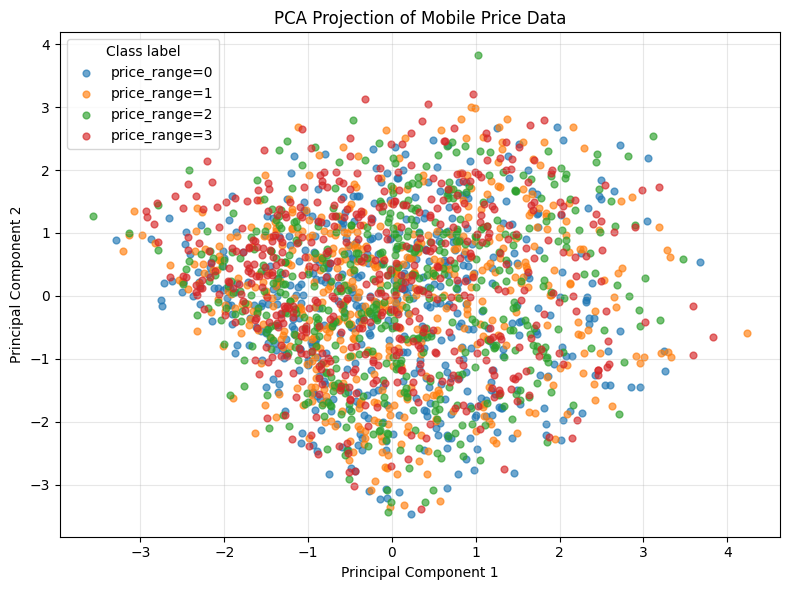

In [29]:
# HW2 Section 4(b): project standardized features to 2D using PCA and visualize true labels
pca_2d = PCA(n_components=2, random_state=42)
X_mobile_pca = pca_2d.fit_transform(X_mobile_scaled)

pca_df = pd.DataFrame(X_mobile_pca, columns=['PC1', 'PC2'])
pca_df['price_range'] = y_mobile_all.values

print('Explained variance ratio:')
print(f"PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total: {pca_2d.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(8, 6))
for label in sorted(pca_df['price_range'].unique()):
    subset = pca_df[pca_df['price_range'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], s=24, alpha=0.65, label=f'price_range={label}')

plt.title('PCA Projection of Mobile Price Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class label')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Section 4(c): K-Means with All Standardized Features


Adjusted Rand Index using all standardized features: 0.0060


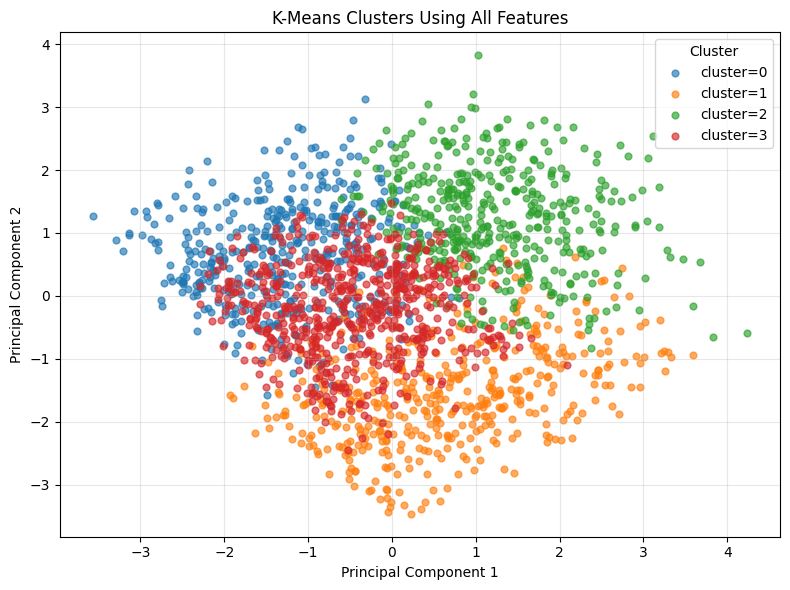

In [30]:
# HW2 Section 4(c): K-means using all standardized features, visualized in PCA space
kmeans_all_features = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_all_features = kmeans_all_features.fit_predict(X_mobile_scaled)
ari_all_features = adjusted_rand_score(y_mobile_all, clusters_all_features)

print(f'Adjusted Rand Index using all standardized features: {ari_all_features:.4f}')

cluster_all_df = pca_df.copy()
cluster_all_df['cluster'] = clusters_all_features

plt.figure(figsize=(8, 6))
for cluster_id in sorted(cluster_all_df['cluster'].unique()):
    subset = cluster_all_df[cluster_all_df['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'], s=24, alpha=0.65, label=f'cluster={cluster_id}')

plt.title('K-Means Clusters Using All Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Section 4(d): K-Means with PCA 2D Features


Adjusted Rand Index using 2D PCA features: 0.0017


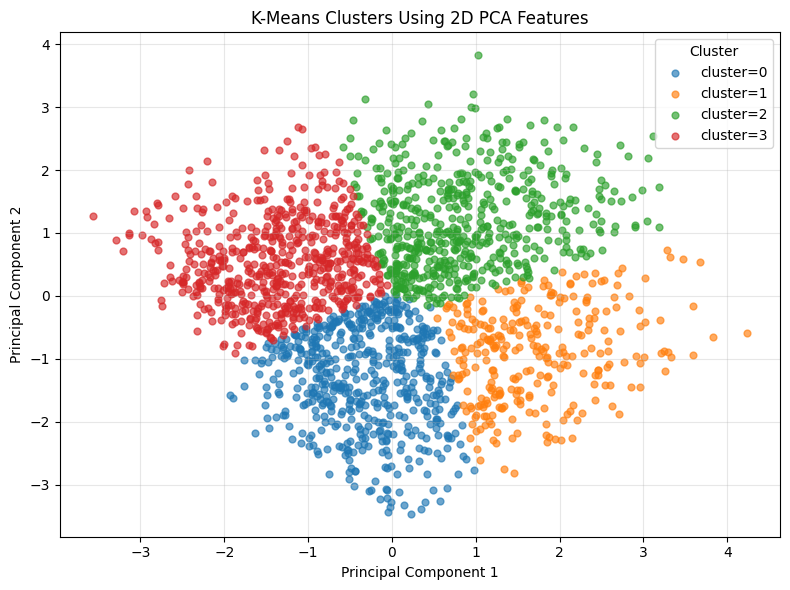

,method,adjusted_rand_score
0,K-Means on all standardized features,0.0060
1,K-Means on 2D PCA features,0.0017


In [31]:
# HW2 Section 4(d): K-means using only the 2-dimensional PCA features
kmeans_pca_features = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_pca_features = kmeans_pca_features.fit_predict(X_mobile_pca)
ari_pca_features = adjusted_rand_score(y_mobile_all, clusters_pca_features)

print(f'Adjusted Rand Index using 2D PCA features: {ari_pca_features:.4f}')

cluster_pca_df = pca_df.copy()
cluster_pca_df['cluster'] = clusters_pca_features

plt.figure(figsize=(8, 6))
for cluster_id in sorted(cluster_pca_df['cluster'].unique()):
    subset = cluster_pca_df[cluster_pca_df['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'], s=24, alpha=0.65, label=f'cluster={cluster_id}')

plt.title('K-Means Clusters Using 2D PCA Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

section4_results = pd.DataFrame([
    {'method': 'K-Means on all standardized features', 'adjusted_rand_score': ari_all_features},
    {'method': 'K-Means on 2D PCA features', 'adjusted_rand_score': ari_pca_features},
])
display(section4_results.style.format({'adjusted_rand_score': '{:.4f}'}))


### Section 4(e): Observations


In [32]:
# HW2 Section 4(e): compare K-means performance from 4(c) and 4(d)
print('Observations:')
print(
    f"1. The first two principal components explain {pca_2d.explained_variance_ratio_.sum():.4f} "
    "of the total standardized feature variance, so the 2D PCA plot is useful for visualization "
    "but does not preserve all information."
)
print(
    f"2. K-means using all standardized features obtains ARI={ari_all_features:.4f}, while "
    f"K-means using only the 2D PCA features obtains ARI={ari_pca_features:.4f}."
)
if ari_all_features >= ari_pca_features:
    print(
        "3. The all-feature clustering performs better or equal by ARI, which suggests that useful "
        "class-separation information is lost when reducing the data to only two PCA components."
    )
else:
    print(
        "3. The PCA-feature clustering performs better by ARI, suggesting that the first two PCs "
        "remove some noise and keep the strongest clustering structure."
    )
print(
    "4. The clusters are not expected to perfectly match price_range labels because K-means is "
    "unsupervised and optimizes geometric compactness rather than class labels."
)


Observations:
1. The first two principal components explain 0.1650 of the total standardized feature variance, so the 2D PCA plot is useful for visualization but does not preserve all information.
2. K-means using all standardized features obtains ARI=0.0060, while K-means using only the 2D PCA features obtains ARI=0.0017.
3. The all-feature clustering performs better or equal by ARI, which suggests that useful class-separation information is lost when reducing the data to only two PCA components.
4. The clusters are not expected to perfectly match price_range labels because K-means is unsupervised and optimizes geometric compactness rather than class labels.


## Section 5: Enhancing K-Means with Association Rule Mining


### Section 5: Method Design

**ARM-guided feature weighting for K-means**

The merged method uses association rule mining as a feature-importance discovery step before clustering. K-means treats every standardized feature equally, but some mobile specifications are more strongly associated with the price-range structure than others. The improved method therefore:

1. Discretizes every feature into low, medium, and high groups using equal-width intervals.
2. Adds the class item `price_range_k` to each transaction and mines frequent itemsets/rules.
3. Keeps association rules whose consequent contains a price-range item and whose lift is greater than 1.
4. Converts the rule strengths into raw feature weights using `support * confidence * lift`.
5. Runs K-means on standardized features multiplied by the ARM-derived raw strength weights.

This merged implementation performs better than the normalized square-root weighting variant from the earlier Section 5(a)-(d) cells, so the Section 5 source and report now use the raw-strength weighting consistently.


### Section 5(a): Mine Label-Associated Rules and Build Feature Weights


In [1]:
# HW2 Section 5(a): merged ARM-guided feature weighting using all mobile_price features
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from mlxtend.frequent_patterns import fpgrowth, association_rules

try:
    mobile_df
except NameError:
    mobile_df = pd.read_csv('data/mobile_price.csv')

X_section5 = mobile_df.drop(columns=['price_range'])
y_section5 = mobile_df['price_range'].to_numpy()
section5_features = X_section5.columns.tolist()

section5_scaler = StandardScaler()
X_section5_scaled = section5_scaler.fit_transform(X_section5)

section5_discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
X_section5_disc = section5_discretizer.fit_transform(X_section5).astype(int)
section5_bin_labels = ['low', 'medium', 'high']

arm_transactions_5 = []
for i in range(len(X_section5_disc)):
    transaction = [
        f'{section5_features[j]}_{section5_bin_labels[X_section5_disc[i, j]]}'
        for j in range(X_section5_disc.shape[1])
    ]
    transaction.append(f'price_range_{y_section5[i]}')
    arm_transactions_5.append(transaction)

all_items_5 = sorted({item for transaction in arm_transactions_5 for item in transaction})
transaction_df_5 = pd.DataFrame(
    [[item in transaction for item in all_items_5] for transaction in arm_transactions_5],
    columns=all_items_5,
)

min_support_5 = 0.05
min_lift_5 = 1.00

frequent_itemsets_5 = fpgrowth(transaction_df_5, min_support=min_support_5, use_colnames=True)
all_rules_5 = association_rules(frequent_itemsets_5, metric='lift', min_threshold=min_lift_5)

label_items_5 = {f'price_range_{label}' for label in sorted(np.unique(y_section5))}
label_rules_5 = all_rules_5[
    all_rules_5['consequents'].apply(lambda items: bool(items & label_items_5))
].copy()
label_rules_5 = label_rules_5[label_rules_5['lift'] > min_lift_5].copy()
label_rules_5['strength'] = (
    label_rules_5['support'] * label_rules_5['confidence'] * label_rules_5['lift']
)

feature_rule_scores = {feature: 0.0 for feature in section5_features}
for _, rule in label_rules_5.iterrows():
    rule_strength = float(rule['strength'])
    for item in rule['antecedents']:
        for feature in section5_features:
            if item.startswith(feature + '_'):
                feature_rule_scores[feature] += rule_strength

raw_scores = np.array([feature_rule_scores[feature] for feature in section5_features])
arm_weight_values = raw_scores.copy()
arm_weight_values[arm_weight_values == 0] = 1e-6
X_section5_arm_weighted = X_section5_scaled * arm_weight_values

feature_weights_df = pd.DataFrame({
    'feature': section5_features,
    'feature_weight': raw_scores,
}).sort_values('feature_weight', ascending=False).reset_index(drop=True)

label_rules_display_5 = label_rules_5.copy()
label_rules_display_5['antecedents_text'] = label_rules_display_5['antecedents'].apply(lambda items: ', '.join(sorted(items)))
label_rules_display_5['consequents_text'] = label_rules_display_5['consequents'].apply(lambda items: ', '.join(sorted(items)))
label_rules_display_5 = label_rules_display_5.sort_values(
    'strength', ascending=False
).reset_index(drop=True)

print(f'Frequent itemsets mined: {len(frequent_itemsets_5)}')
print(f'Label-associated rules kept: {len(label_rules_5)}')
print('\nTop ARM-derived feature weights:')
print(feature_weights_df.head(12).round(4).to_string(index=False))

print('\nTop label-associated rules:')
print(label_rules_display_5[
    ['antecedents_text', 'consequents_text', 'support', 'confidence', 'lift', 'strength']
].head(10).round(4).to_string(index=False))


Frequent itemsets mined: 25003
Label-associated rules kept: 8554

Top ARM-derived feature weights:
      feature  feature_weight
          ram        267.4954
      three_g         85.7715
           fc         71.5829
       four_g         57.3444
    px_height         47.0483
     dual_sim         32.4341
         wifi         30.8988
 touch_screen         30.6776
         blue         29.4685
         sc_w         21.1516
battery_power         17.3874
     px_width         15.2128

Top label-associated rules:
              antecedents_text            consequents_text  support  confidence   lift  strength
                      ram_high               price_range_3   0.2340      0.7222 2.8889    0.4882
                       ram_low               price_range_0   0.2420      0.7097 2.8387    0.4875
        px_height_low, ram_low               price_range_0   0.1600      0.8355 3.3420    0.4468
        ram_high, three_g_high               price_range_3   0.1815      0.7348 2.9393    0.39

### Section 5(b): Compare Original K-Means and ARM-Guided K-Means


In [2]:
# HW2 Section 5(b): compare original K-means and ARM-guided K-means over required random seeds
seeds_5 = [0, 10, 42, 100, 999]


def map_clusters_to_labels(y_true, cluster_ids):
    true_labels = np.array(sorted(np.unique(y_true)))
    clusters = np.array(sorted(np.unique(cluster_ids)))
    match_matrix = np.zeros((len(clusters), len(true_labels)), dtype=int)

    for i, cluster in enumerate(clusters):
        for j, label in enumerate(true_labels):
            match_matrix[i, j] = np.sum((cluster_ids == cluster) & (y_true == label))

    row_ind, col_ind = linear_sum_assignment(-match_matrix)
    cluster_to_label = {clusters[row]: true_labels[col] for row, col in zip(row_ind, col_ind)}
    return np.array([cluster_to_label[cluster] for cluster in cluster_ids])


def evaluate_kmeans_dataset(X_data, method_name):
    records = []
    for random_seed in seeds_5:
        kmeans = KMeans(n_clusters=4, random_state=random_seed, n_init=10)
        cluster_ids = kmeans.fit_predict(X_data)
        y_pred = map_clusters_to_labels(y_section5, cluster_ids)

        records.append({
            'method': method_name,
            'seed': random_seed,
            'accuracy': accuracy_score(y_section5, y_pred),
            'precision_weighted': precision_score(y_section5, y_pred, average='weighted', zero_division=0),
            'recall_weighted': recall_score(y_section5, y_pred, average='weighted', zero_division=0),
            'f1_weighted': f1_score(y_section5, y_pred, average='weighted', zero_division=0),
        })
    return pd.DataFrame(records)


original_kmeans_results_5 = evaluate_kmeans_dataset(
    X_section5_scaled,
    'Original K-means',
)
arm_kmeans_results_5 = evaluate_kmeans_dataset(
    X_section5_arm_weighted,
    'ARM-guided weighted K-means',
)

section5_seed_results = pd.concat([original_kmeans_results_5, arm_kmeans_results_5], ignore_index=True)
section5_average_results = section5_seed_results.groupby('method', as_index=False)[
    ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
].mean()

print('Per-seed clustering performance:')
print(section5_seed_results.round(4).to_string(index=False))

print('\nAverage performance over seeds [0, 10, 42, 100, 999]:')
print(section5_average_results.round(4).to_string(index=False))

plot_df = section5_average_results.melt(
    id_vars='method',
    value_vars=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(10, 5))
for method_name in plot_df['method'].unique():
    subset = plot_df[plot_df['method'] == method_name]
    plt.plot(subset['metric'], subset['score'], marker='o', label=method_name)

plt.title('Average K-Means Performance over Required Seeds')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Per-seed clustering performance:
                     method  seed  accuracy  precision_weighted  recall_weighted  f1_weighted
           Original K-means     0    0.2945              0.2940           0.2945       0.2926
           Original K-means    10    0.2955              0.2953           0.2955       0.2936
           Original K-means    42    0.2970              0.2966           0.2970       0.2950
           Original K-means   100    0.2955              0.2950           0.2955       0.2935
           Original K-means   999    0.2985              0.2984           0.2985       0.2956
ARM-guided weighted K-means     0    0.7505              0.7546           0.7505       0.7517
ARM-guided weighted K-means    10    0.7510              0.7560           0.7510       0.7523
ARM-guided weighted K-means    42    0.7505              0.7550           0.7505       0.7518
ARM-guided weighted K-means   100    0.7515              0.7561           0.7515       0.7528
ARM-guided weighted K-means

### Section 5(c): Observations and Analysis


In [3]:
# HW2 Section 5(c): summarize the Section 5 comparison
original_avg_5 = section5_average_results[section5_average_results['method'] == 'Original K-means'].iloc[0]
arm_avg_5 = section5_average_results[section5_average_results['method'] == 'ARM-guided weighted K-means'].iloc[0]

print('Observations:')
print(
    f"1. Original K-means reaches average Accuracy={original_avg_5['accuracy']:.4f}, "
    f"Precision={original_avg_5['precision_weighted']:.4f}, Recall={original_avg_5['recall_weighted']:.4f}, "
    f"and F1={original_avg_5['f1_weighted']:.4f} over the required seeds."
)
print(
    f"2. ARM-guided weighted K-means reaches average Accuracy={arm_avg_5['accuracy']:.4f}, "
    f"Precision={arm_avg_5['precision_weighted']:.4f}, Recall={arm_avg_5['recall_weighted']:.4f}, "
    f"and F1={arm_avg_5['f1_weighted']:.4f}."
)
print(
    f"3. The F1 improvement is {arm_avg_5['f1_weighted'] - original_avg_5['f1_weighted']:.4f}, "
    "showing that ARM-derived feature weighting makes K-means align better with the price-range labels."
)
print(
    "4. The improvement comes from emphasizing features that appear in high-support, high-confidence, "
    "lift-positive rules for the price ranges. This changes the distance geometry used by K-means "
    "without changing the clustering algorithm itself."
)
print(
    "5. A limitation is that the ARM weighting step uses label-consequent rules, so this method is best "
    "viewed as a semi-supervised enhancement rather than a purely unsupervised clustering method."
)


Observations:
1. Original K-means reaches average Accuracy=0.2962, Precision=0.2959, Recall=0.2962, and F1=0.2941 over the required seeds.
2. ARM-guided weighted K-means reaches average Accuracy=0.7509, Precision=0.7555, Recall=0.7509, and F1=0.7522.
3. The F1 improvement is 0.4581, showing that ARM-derived feature weighting makes K-means align better with the price-range labels.
4. The improvement comes from emphasizing features that appear in high-support, high-confidence, lift-positive rules for the price ranges. This changes the distance geometry used by K-means without changing the clustering algorithm itself.
5. A limitation is that the ARM weighting step uses label-consequent rules, so this method is best viewed as a semi-supervised enhancement rather than a purely unsupervised clustering method.


### Section 5(d): Clustering Visualizations (PCA Space)


In [4]:
# HW2 Section 5(d): visualize Original and ARM-guided K-means clusters in PCA 2D space
from sklearn.decomposition import PCA

# Reuse the same PCA as Section 4 (fit on the same standardized features)
pca_viz_5 = PCA(n_components=2, random_state=42)
X_section5_pca2d = pca_viz_5.fit_transform(X_section5_scaled)

# Use seed=42 for a representative single-run visualization
viz_seed = 42
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# --- Original K-means ---
km_orig_viz = KMeans(n_clusters=4, random_state=viz_seed, n_init=10)
orig_clusters_viz = km_orig_viz.fit_predict(X_section5_scaled)
orig_mapped = map_clusters_to_labels(y_section5, orig_clusters_viz)

fig, ax = plt.subplots(figsize=(8, 6))
for label in sorted(np.unique(orig_mapped)):
    mask = orig_mapped == label
    ax.scatter(X_section5_pca2d[mask, 0], X_section5_pca2d[mask, 1],
               s=20, alpha=0.6, color=colors[label], label=f'Predicted label={label}')
ax.set_title('Original K-Means Clustering (PCA 2D View)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Mapped Label')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('section5-1.png', dpi=150)
plt.show()
print('Saved section5-1.png')

# --- ARM-guided K-means ---
km_arm_viz = KMeans(n_clusters=4, random_state=viz_seed, n_init=10)
arm_clusters_viz = km_arm_viz.fit_predict(X_section5_arm_weighted)
arm_mapped = map_clusters_to_labels(y_section5, arm_clusters_viz)

fig, ax = plt.subplots(figsize=(8, 6))
for label in sorted(np.unique(arm_mapped)):
    mask = arm_mapped == label
    ax.scatter(X_section5_pca2d[mask, 0], X_section5_pca2d[mask, 1],
               s=20, alpha=0.6, color=colors[label], label=f'Predicted label={label}')
ax.set_title('ARM-Guided K-Means Clustering (PCA 2D View)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Mapped Label')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('section5-2.png', dpi=150)
plt.show()
print('Saved section5-2.png')


Saved section5-1.png
Saved section5-2.png
